In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision.datasets as datasets
import os
from scipy.interpolate import interp1d
%matplotlib inline

/home/ddsukhoverkhova/.conda/envs/mc_lib_env/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
plt.rcParams['axes.grid'] = True

In [5]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

In [6]:
Jd = 0.0

num_temps = 100
T_c = get_crit_T[Jd]
T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f) 
L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 

In [7]:
def errs(errs):
    return np.array([sum(errs[i*512:(i+1)*512])/512 for i in range(num_temps)])

def stds_err(errs):
    return np.array([np.std(errs[i*512:(i+1)*512]) for i in range(num_temps)])

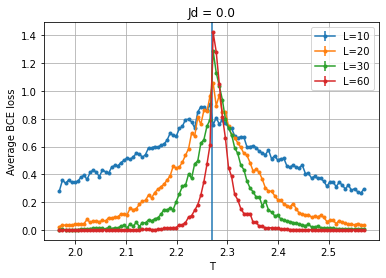

In [207]:
plt.errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
plt.errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
plt.errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c)
plt.legend()
#plt.xlim(T_c-0.01, T_c+0.01)
plt.show()

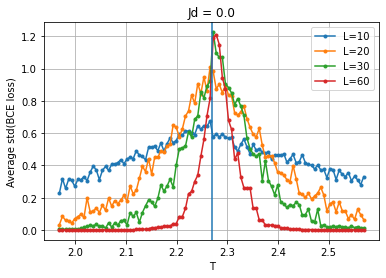

In [208]:
# погрешности

plt.plot(T, stds_err(errs_10), marker='.', label='L=10')
plt.plot(T, stds_err(errs_20), marker='.', label='L=20')
plt.plot(T, stds_err(errs_30), marker='.', label='L=30')
plt.plot(T, stds_err(errs_60), marker='.', label='L=60')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average std(BCE loss)')
plt.axvline(x=T_c)
plt.legend()
#plt.xlim(T_c-0.01, T_c+0.01)
plt.show()

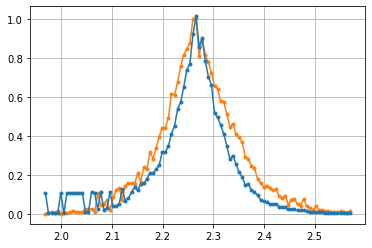

In [9]:
plt.errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=60')
plt.plot(T, stds_err(errs_30), marker='.', label='L=60')
plt.show()

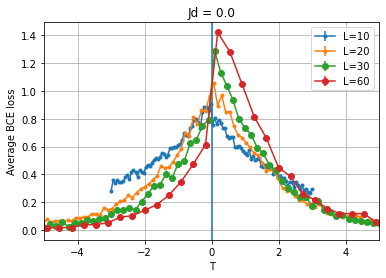

In [172]:
plt.errorbar((T-T_c)*10, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
plt.errorbar((T-T_c)*20, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
plt.errorbar((T-T_c)*30, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='o', label='L=30')
plt.errorbar((T-T_c)*60, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='o', label='L=60')


plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=0.0)
#plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.xlim((-5, 5))
plt.show()

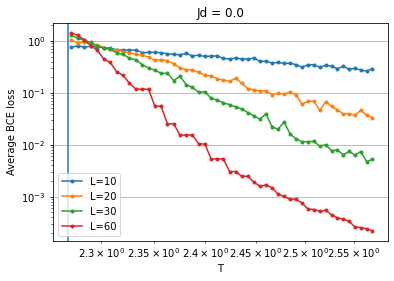

In [154]:
plt.plot(T[T>=T_c], errs(errs_10)[T>=T_c], marker='.', label='L=10')
plt.plot(T[T>=T_c], errs(errs_20)[T>=T_c], marker='.', label='L=20')
plt.plot(T[T>=T_c], errs(errs_30)[T>=T_c], marker='.', label='L=30')
plt.plot(T[T>=T_c], errs(errs_60)[T>=T_c], marker='.', label='L=60')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

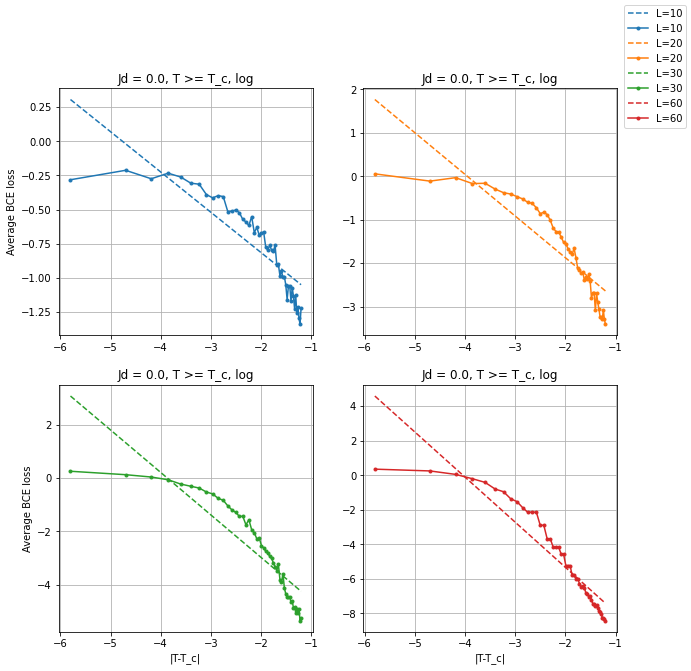

In [189]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

pf_10 = np.polyfit(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_10)[50:]), 1)
pf_20 = np.polyfit(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_20)[50:]), 1)
pf_30 = np.polyfit(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_30)[50:]), 1)
pf_60 = np.polyfit(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_60)[50:]), 1)

ax[0, 0].plot(np.log(np.abs(T-T_c)[50:]), np.poly1d(pf_10)(np.log(np.abs(T-T_c)))[50:], '--', label='L=10', c='C0')
ax[0, 1].plot(np.log(np.abs(T-T_c)[50:]), np.poly1d(pf_20)(np.log(np.abs(T-T_c)))[50:], '--', label='L=20', c='C1')
ax[1, 0].plot(np.log(np.abs(T-T_c)[50:]), np.poly1d(pf_30)(np.log(np.abs(T-T_c)))[50:], '--', label='L=30', c='C2')
ax[1, 1].plot(np.log(np.abs(T-T_c)[50:]), np.poly1d(pf_60)(np.log(np.abs(T-T_c)))[50:], '--', label='L=60', c='C3')

ax[0, 0].plot(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_10)[50:]), marker='.', label='L=10', c='C0')
ax[0, 1].plot(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_20)[50:]), marker='.', label='L=20', c='C1')
ax[1, 0].plot(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_30)[50:]), marker='.', label='L=30', c='C2')
ax[1, 1].plot(np.log(np.abs(T-T_c)[50:]), np.log(errs(errs_60)[50:]), marker='.', label='L=60', c='C3')

plt.setp(ax[-1, :], xlabel='|T-T_c|')
plt.setp(ax[:, 0], ylabel='Average BCE loss')
plt.setp(ax, title='Jd = 0.0, T >= T_c, log')
#plt.xscale('log')
#plt.yscale('log')
fig.legend()
plt.show()

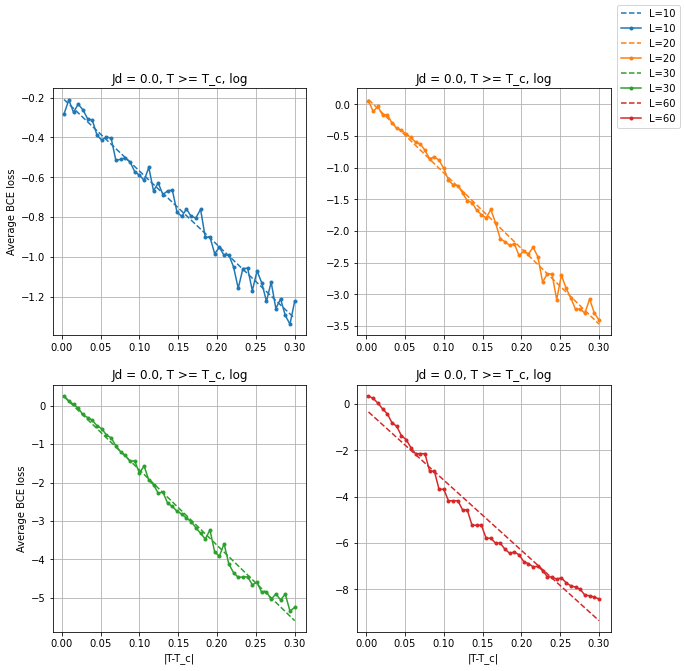

In [197]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

pf_10 = np.polyfit(np.abs(T-T_c)[50:], np.log(errs(errs_10)[50:]), 1)
pf_20 = np.polyfit(np.abs(T-T_c)[50:], np.log(errs(errs_20)[50:]), 1)
pf_30 = np.polyfit(np.abs(T-T_c)[50:], np.log(errs(errs_30)[50:]), 1)
pf_60 = np.polyfit(np.abs(T-T_c)[50:], np.log(errs(errs_60)[50:]), 1)

ax[0, 0].plot(np.abs(T-T_c)[50:], np.poly1d(pf_10)(np.abs(T-T_c))[50:], '--', label='L=10', c='C0')
ax[0, 1].plot(np.abs(T-T_c)[50:], np.poly1d(pf_20)(np.abs(T-T_c))[50:], '--', label='L=20', c='C1')
ax[1, 0].plot(np.abs(T-T_c)[50:], np.poly1d(pf_30)(np.abs(T-T_c))[50:], '--', label='L=30', c='C2')
ax[1, 1].plot(np.abs(T-T_c)[50:], np.poly1d(pf_60)(np.abs(T-T_c))[50:], '--', label='L=60', c='C3')

ax[0, 0].plot(np.abs(T-T_c)[50:], np.log(errs(errs_10)[50:]), marker='.', label='L=10', c='C0')
ax[0, 1].plot(np.abs(T-T_c)[50:], np.log(errs(errs_20)[50:]), marker='.', label='L=20', c='C1')
ax[1, 0].plot(np.abs(T-T_c)[50:], np.log(errs(errs_30)[50:]), marker='.', label='L=30', c='C2')
ax[1, 1].plot(np.abs(T-T_c)[50:], np.log(errs(errs_60)[50:]), marker='.', label='L=60', c='C3')

plt.setp(ax[-1, :], xlabel='|T-T_c|')
plt.setp(ax[:, 0], ylabel='Average BCE loss')
plt.setp(ax, title='Jd = 0.0, T >= T_c, log')
#plt.xscale('log')
#plt.yscale('log')
fig.legend()
plt.show()

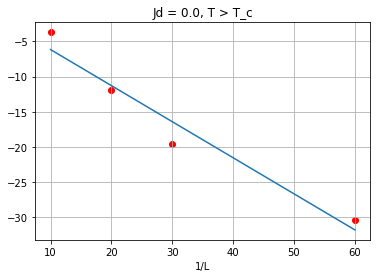

In [198]:
ls = [L for L in [10, 20, 30, 60]]

cs = [pf_10[0], pf_20[0], pf_30[0], pf_60[0]]

plt.scatter(ls, cs, color='red')
plt.plot(ls, np.poly1d(np.polyfit(ls, cs, 1))(ls))
plt.title('Jd = 0.0, T > T_c')
plt.xlabel('1/L')
plt.show()

In [195]:
cs

[-3.698977462533882,
 -11.9421769676094,
 -19.647504884408892,
 -30.379265242956006]

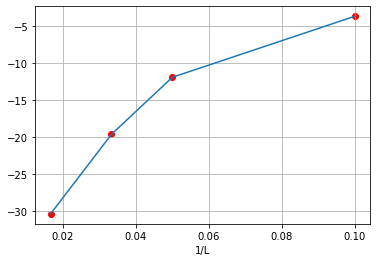

In [192]:
f = interp1d(ls, cs)

plt.scatter(ls, cs, color='red')
plt.plot(ls, f(ls))
plt.xlabel('1/L')
plt.show()

In [159]:
Jd = 0.0
np.save(f'data_errors/{Jd}_10_pf_above.npy', pf_10)
np.save(f'data_errors/{Jd}_20_pf_above.npy', pf_20)
np.save(f'data_errors/{Jd}_30_pf_above.npy', pf_30)
np.save(f'data_errors/{Jd}_60_pf_above.npy', pf_60)

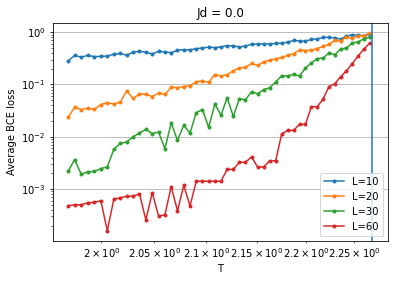

In [160]:
plt.plot(T[T<=T_c], errs(errs_10)[T<=T_c], marker='.', label='L=10')
plt.plot(T[T<=T_c], errs(errs_20)[T<=T_c], marker='.', label='L=20')
plt.plot(T[T<=T_c], errs(errs_30)[T<=T_c], marker='.', label='L=30')
plt.plot(T[T<=T_c], errs(errs_60)[T<=T_c], marker='.', label='L=60')

plt.title('Jd = 0.0')
plt.xlabel('T')
plt.ylabel('Average BCE loss')
plt.axvline(x=T_c)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

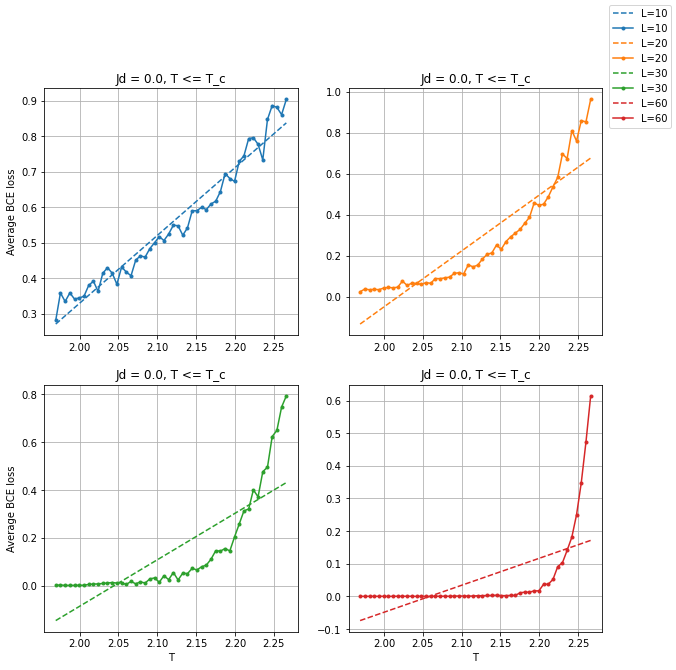

In [161]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

pf_10 = np.polyfit(T[T<=T_c], errs(errs_10)[T<=T_c], 1)
pf_20 = np.polyfit(T[T<=T_c], errs(errs_20)[T<=T_c], 1)
pf_30 = np.polyfit(T[T<=T_c], errs(errs_30)[T<=T_c], 1)
pf_60 = np.polyfit(T[T<=T_c], errs(errs_60)[T<=T_c], 1)

ax[0, 0].plot(T[T<=T_c], np.poly1d(pf_10)(T[T<=T_c]), '--', label='L=10', c='C0')
ax[0, 1].plot(T[T<=T_c], np.poly1d(pf_20)(T[T<=T_c]), '--', label='L=20', c='C1')
ax[1, 0].plot(T[T<=T_c], np.poly1d(pf_30)(T[T<=T_c]), '--', label='L=30', c='C2')
ax[1, 1].plot(T[T<=T_c], np.poly1d(pf_60)(T[T<=T_c]), '--', label='L=60', c='C3')

ax[0, 0].plot(T[T<=T_c], errs(errs_10)[T<=T_c], marker='.', label='L=10', c='C0')
ax[0, 1].plot(T[T<=T_c], errs(errs_20)[T<=T_c], marker='.', label='L=20', c='C1')
ax[1, 0].plot(T[T<=T_c], errs(errs_30)[T<=T_c], marker='.', label='L=30', c='C2')
ax[1, 1].plot(T[T<=T_c], errs(errs_60)[T<=T_c], marker='.', label='L=60', c='C3')


plt.setp(ax[-1, :], xlabel='T')
plt.setp(ax[:, 0], ylabel='Average BCE loss')
plt.setp(ax, title='Jd = 0.0, T <= T_c')
fig.legend()
plt.show()

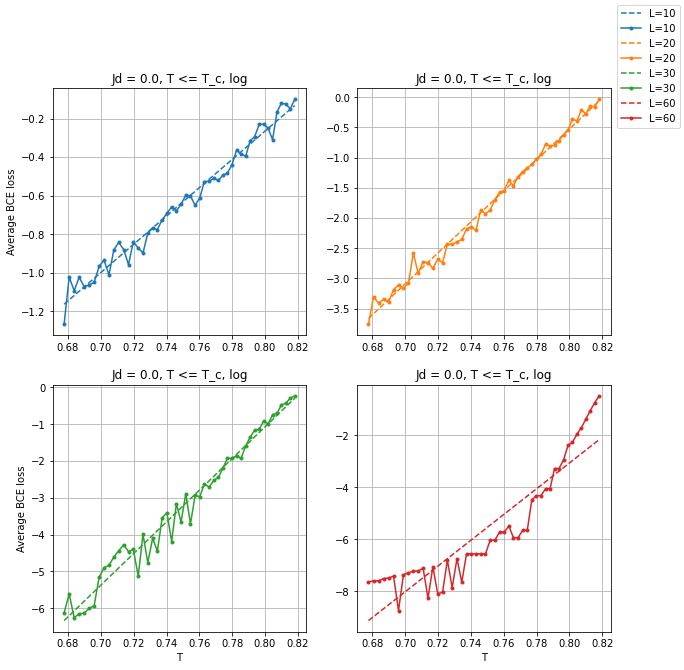

In [162]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

pf_10 = np.polyfit(np.log(T[T<=T_c]), np.log(errs(errs_10)[T<=T_c]), 1)
pf_20 = np.polyfit(np.log(T[T<=T_c]), np.log(errs(errs_20)[T<=T_c]), 1)
pf_30 = np.polyfit(np.log(T[T<=T_c]), np.log(errs(errs_30)[T<=T_c]), 1)
pf_60 = np.polyfit(np.log(T[T<=T_c]), np.log(errs(errs_60)[T<=T_c]), 1)

ax[0, 0].plot(np.log(T[T<=T_c]), np.poly1d(pf_10)(np.log(T[T<=T_c])), '--', label='L=10', c='C0')
ax[0, 1].plot(np.log(T[T<=T_c]), np.poly1d(pf_20)(np.log(T[T<=T_c])), '--', label='L=20', c='C1')
ax[1, 0].plot(np.log(T[T<=T_c]), np.poly1d(pf_30)(np.log(T[T<=T_c])), '--', label='L=30', c='C2')
ax[1, 1].plot(np.log(T[T<=T_c]), np.poly1d(pf_60)(np.log(T[T<=T_c])), '--', label='L=60', c='C3')

ax[0, 0].plot(np.log(T[T<=T_c]), np.log(errs(errs_10)[T<=T_c]), marker='.', label='L=10', c='C0')
ax[0, 1].plot(np.log(T[T<=T_c]), np.log(errs(errs_20)[T<=T_c]), marker='.', label='L=20', c='C1')
ax[1, 0].plot(np.log(T[T<=T_c]), np.log(errs(errs_30)[T<=T_c]), marker='.', label='L=30', c='C2')
ax[1, 1].plot(np.log(T[T<=T_c]), np.log(errs(errs_60)[T<=T_c]), marker='.', label='L=60', c='C3')

plt.setp(ax[-1, :], xlabel='T')
plt.setp(ax[:, 0], ylabel='Average BCE loss')
plt.setp(ax, title='Jd = 0.0, T <= T_c, log')
fig.legend()
plt.show()

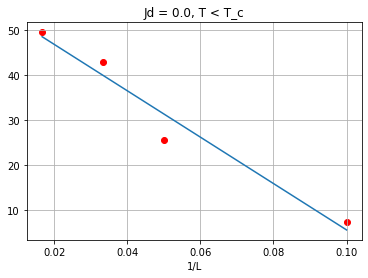

In [163]:
ls = [1/L for L in [10, 20, 30, 60]]

cs = [pf_10[0], pf_20[0], pf_30[0], pf_60[0]]

plt.scatter(ls, cs, color='red')
plt.plot(ls, np.poly1d(np.polyfit(ls, cs, 1))(ls))
plt.title('Jd = 0.0, T < T_c')
plt.xlabel('1/L')
plt.show()

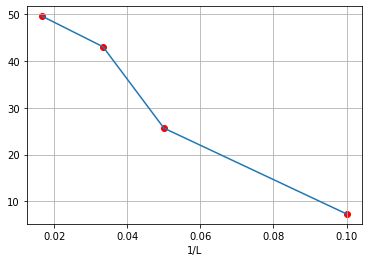

In [164]:
f = interp1d(ls, cs)

plt.scatter(ls, cs, color='red')
plt.plot(ls, f(ls))
plt.xlabel('1/L')
plt.show()

In [165]:
Jd = 0.0
np.save(f'data_errors/{Jd}_10_pf_below.npy', pf_10)
np.save(f'data_errors/{Jd}_20_pf_below.npy', pf_20)
np.save(f'data_errors/{Jd}_30_pf_below.npy', pf_30)
np.save(f'data_errors/{Jd}_60_pf_below.npy', pf_60)